# WCCI Do-Nothing And Greedy Monthly Analysis

This notebook analyzes the downloaded WCCI `bus36_wcci` evaluation outputs by month first.

It loads:
- do-nothing evaluations for train, test, and all chronics,
- the 50-random-chronic full-greedy evaluation without replayed do-nothing,
- an optional paired greedy-with-do-nothing rerun if you point `GREEDY_RUN` to that folder.

Every plotting cell prints the exact source files used just before the figure is drawn.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

def find_task_dir(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == "Topology_Task" and (candidate / "outputs").exists():
            return candidate
        nested = candidate / "Topology_Task"
        if (nested / "outputs").exists():
            return nested
    raise FileNotFoundError("Could not find Topology_Task/outputs from the current working directory.")

TASK_DIR = find_task_dir()
OUTPUTS_DIR = TASK_DIR / "outputs"

DO_NOTHING_RUNS = {
    "train": OUTPUTS_DIR / "do_nothing_eval" / "wcci_train_detmaint",
    "test": OUTPUTS_DIR / "do_nothing_eval" / "wcci_test_detmaint",
    "all": OUTPUTS_DIR / "do_nothing_eval" / "wcci_all_detmaint",
}

# Change this to the paired rerun folder once it is downloaded, e.g.
# OUTPUTS_DIR / "teacher_student_greedy_eval" / "wcci_h1_mk256_test_50chronics_withdn"
GREEDY_RUN = OUTPUTS_DIR / "wcci_h1_mk256_test_50chronics_nodn"

MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
MONTH_NAME_TO_NUM = {name.lower(): i + 1 for i, name in enumerate([
    "january", "february", "march", "april", "may", "june", "july", "august", "september", "october", "november", "december"
])}

print(f"Task dir: {TASK_DIR}")
print(f"Outputs dir: {OUTPUTS_DIR}")

Task dir: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task
Outputs dir: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs


In [2]:
def require_file(path: Path) -> Path:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return path

def read_json(path: Path):
    with require_file(path).open("r", encoding="utf-8") as f:
        return json.load(f)

def as_bool(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.lower().map({"true": True, "false": False}).fillna(False)

def month_from_name(name):
    text = str(name).lower()
    match = re.search(r"scenario_([a-z]+)_", text)
    if not match:
        return np.nan
    return MONTH_NAME_TO_NUM.get(match.group(1), np.nan)

def add_month_columns(df, datetime_col, name_col):
    out = df.copy()
    dt = pd.to_datetime(out[datetime_col], errors="coerce") if datetime_col in out else pd.Series(pd.NaT, index=out.index)
    month_num = dt.dt.month.astype("float")
    if name_col in out:
        fallback = out[name_col].map(month_from_name)
        month_num = month_num.fillna(fallback)
    out["month_num"] = month_num.astype("Int64")
    out["month"] = out["month_num"].map(lambda x: MONTH_NAMES[int(x) - 1] if pd.notna(x) else "unknown")
    return out

def pct(series):
    return 100.0 * pd.to_numeric(series, errors="coerce")

def rel(path: Path) -> str:
    path = Path(path).resolve()
    try:
        return str(path.relative_to(TASK_DIR.resolve()))
    except ValueError:
        return str(path)

def print_plot_sources(title, paths):
    print(f"Plot source files for {title}:")
    for path in paths:
        print(f"  - {rel(Path(path))}")

def load_do_nothing_run(split, folder):
    folder = Path(folder)
    csv_path = require_file(folder / "do_nothing_episodes.csv")
    json_path = require_file(folder / "do_nothing_summary.json")
    df = pd.read_csv(csv_path)
    df["dataset_split"] = split
    df["policy"] = "do_nothing"
    df["source_folder"] = str(folder)
    df["source_csv"] = str(csv_path)
    df["survival"] = pd.to_numeric(df["survival"], errors="coerce")
    df["steps"] = pd.to_numeric(df["steps"], errors="coerce")
    df["max_steps"] = pd.to_numeric(df["max_steps"], errors="coerce")
    df["full_survival"] = as_bool(df["full_survival"])
    df = add_month_columns(df, "chronic_datetime", "chronic_name")
    return df, read_json(json_path), {"csv": csv_path, "json": json_path}

def load_greedy_run(folder):
    folder = Path(folder)
    csv_path = require_file(folder / "greedy_vs_do_nothing_episodes.csv")
    json_path = require_file(folder / "greedy_vs_do_nothing_summary.json")
    df = pd.read_csv(csv_path)
    df["policy"] = "greedy"
    df["source_folder"] = str(folder)
    df["source_csv"] = str(csv_path)
    for col in ["greedy_survival", "do_nothing_survival", "survival_delta"]:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    for col in ["greedy_steps", "do_nothing_steps", "max_steps", "greedy_nonidle_actions", "greedy_decision_states", "greedy_simulated_actions"]:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["greedy_full_survival"] = as_bool(df["greedy_full_survival"])
    if "do_nothing_full_survival" in df:
        df["do_nothing_full_survival"] = as_bool(df["do_nothing_full_survival"])
    df = add_month_columns(df, "greedy_chronic_datetime", "greedy_chronic_name")
    return df, read_json(json_path), {"csv": csv_path, "json": json_path}

def month_agg(df, survival_col, full_col=None, extra=None):
    agg = {
        "n": (survival_col, "size"),
        "mean_survival_pct": (survival_col, lambda s: 100.0 * pd.to_numeric(s, errors="coerce").mean()),
        "median_survival_pct": (survival_col, lambda s: 100.0 * pd.to_numeric(s, errors="coerce").median()),
    }
    if full_col is not None:
        agg["full_survival_rate_pct"] = (full_col, lambda s: 100.0 * as_bool(s).mean())
    if extra:
        agg.update(extra)
    result = df.groupby(["month_num", "month"], dropna=False).agg(**agg).reset_index()
    return result.sort_values("month_num")

In [3]:
do_nothing_frames = []
do_nothing_summaries = {}
source_files = {"do_nothing": {}, "greedy": {}}

for split, folder in DO_NOTHING_RUNS.items():
    df, summary, files = load_do_nothing_run(split, folder)
    do_nothing_frames.append(df)
    do_nothing_summaries[split] = summary
    source_files["do_nothing"][split] = files

do_nothing = pd.concat(do_nothing_frames, ignore_index=True)
greedy, greedy_summary, greedy_files = load_greedy_run(GREEDY_RUN)
source_files["greedy"] = greedy_files

source_table = []
for split, files in source_files["do_nothing"].items():
    source_table.append({"kind": "do_nothing", "split": split, "csv": rel(files["csv"]), "json": rel(files["json"])})
source_table.append({"kind": "greedy", "split": greedy_summary.get("split", "unknown"), "csv": rel(greedy_files["csv"]), "json": rel(greedy_files["json"])})

display(pd.DataFrame(source_table))
print(f"Loaded do-nothing episodes: {len(do_nothing):,}")
print(f"Loaded greedy episodes: {len(greedy):,}")

,kind,split,csv,json
0,do_nothing,train,outputs/do_nothing_eval/wcci_train_detmaint/do...,outputs/do_nothing_eval/wcci_train_detmaint/do...
1,do_nothing,test,outputs/do_nothing_eval/wcci_test_detmaint/do_...,outputs/do_nothing_eval/wcci_test_detmaint/do_...
2,do_nothing,all,outputs/do_nothing_eval/wcci_all_detmaint/do_n...,outputs/do_nothing_eval/wcci_all_detmaint/do_n...
3,greedy,test,outputs/wcci_h1_mk256_test_50chronics_nodn/gre...,outputs/wcci_h1_mk256_test_50chronics_nodn/gre...


Loaded do-nothing episodes: 5,760
Loaded greedy episodes: 50


## 1. Global Sanity Check

In [4]:
global_summary = []
for split, summary in do_nothing_summaries.items():
    global_summary.append({
        "policy": "do_nothing",
        "split": split,
        "episodes": summary.get("n_episodes"),
        "unique_fingerprints": summary.get("n_unique_fingerprints"),
        "mean_survival_pct": 100.0 * summary.get("mean_survival", np.nan),
        "median_survival_pct": 100.0 * summary.get("median_survival", np.nan),
        "full_survival_rate_pct": 100.0 * summary.get("full_survival_rate", np.nan),
        "source": rel(source_files["do_nothing"][split]["json"]),
    })

global_summary.append({
    "policy": "greedy",
    "split": greedy_summary.get("split", "unknown"),
    "episodes": greedy_summary.get("n_episodes"),
    "unique_fingerprints": greedy["greedy_chronic_fingerprint"].nunique(),
    "mean_survival_pct": 100.0 * greedy_summary.get("greedy_mean_survival", np.nan),
    "median_survival_pct": 100.0 * greedy["greedy_survival"].median(),
    "full_survival_rate_pct": 100.0 * greedy_summary.get("greedy_full_survival_rate", np.nan),
    "source": rel(greedy_files["json"]),
})

display(pd.DataFrame(global_summary).round(3))

train_mean = do_nothing_summaries["train"]["mean_survival"]
test_mean = do_nothing_summaries["test"]["mean_survival"]
train_n = do_nothing_summaries["train"]["n_episodes"]
test_n = do_nothing_summaries["test"]["n_episodes"]
weighted_train_test = (train_n * train_mean + test_n * test_mean) / (train_n + test_n)
print(f"Weighted train/test do-nothing mean: {100 * weighted_train_test:.3f}%")
print(f"Downloaded all do-nothing mean:       {100 * do_nothing_summaries['all']['mean_survival']:.3f}%")

,policy,split,episodes,unique_fingerprints,mean_survival_pct,median_survival_pct,full_survival_rate_pct,source
0,do_nothing,train,2304,2304,26.422,12.131,6.597,outputs/do_nothing_eval/wcci_train_detmaint/do...
1,do_nothing,test,576,576,27.257,12.143,6.771,outputs/do_nothing_eval/wcci_test_detmaint/do_...
2,do_nothing,all,2880,2880,27.001,12.131,7.465,outputs/do_nothing_eval/wcci_all_detmaint/do_n...
3,greedy,test,50,50,69.431,100.000,56.000,outputs/wcci_h1_mk256_test_50chronics_nodn/gre...


Weighted train/test do-nothing mean: 26.589%
Downloaded all do-nothing mean:       27.001%


## 2. Do-Nothing Results By Month

In [5]:
do_nothing_month = (
    do_nothing.groupby(["dataset_split", "month_num", "month"], dropna=False)
    .agg(
        n=("survival", "size"),
        mean_survival_pct=("survival", lambda s: 100.0 * s.mean()),
        median_survival_pct=("survival", lambda s: 100.0 * s.median()),
        full_survival_rate_pct=("full_survival", lambda s: 100.0 * s.mean()),
        mean_steps=("steps", "mean"),
        mean_peak_rho=("peak_max_rho", "mean"),
    )
    .reset_index()
    .sort_values(["dataset_split", "month_num"])
)

display(do_nothing_month.round(3))

,dataset_split,month_num,month,n,mean_survival_pct,median_survival_pct,full_survival_rate_pct,mean_steps,mean_peak_rho
0,all,1,Jan,240,9.090,8.670,0.000,732.808,1.920
1,all,2,Feb,240,2.561,1.278,0.000,206.467,1.335
2,all,3,Mar,240,22.635,16.497,0.833,1824.833,1.389
3,all,4,Apr,240,53.040,54.999,18.333,4276.067,1.486
4,all,5,May,240,61.958,58.608,31.667,4995.092,1.308
5,all,6,Jun,240,48.827,44.245,17.917,3936.417,1.441
6,all,7,Jul,240,37.621,33.546,5.417,3033.042,1.550
7,all,8,Aug,240,24.709,20.578,2.500,1992.021,1.635
8,all,9,Sep,240,42.925,35.990,12.917,3460.625,1.556
9,all,10,Oct,240,5.176,5.296,0.000,417.254,2.180


Plot source files for do-nothing monthly mean survival:
  - outputs/do_nothing_eval/wcci_train_detmaint/do_nothing_episodes.csv
  - outputs/do_nothing_eval/wcci_test_detmaint/do_nothing_episodes.csv
  - outputs/do_nothing_eval/wcci_all_detmaint/do_nothing_episodes.csv


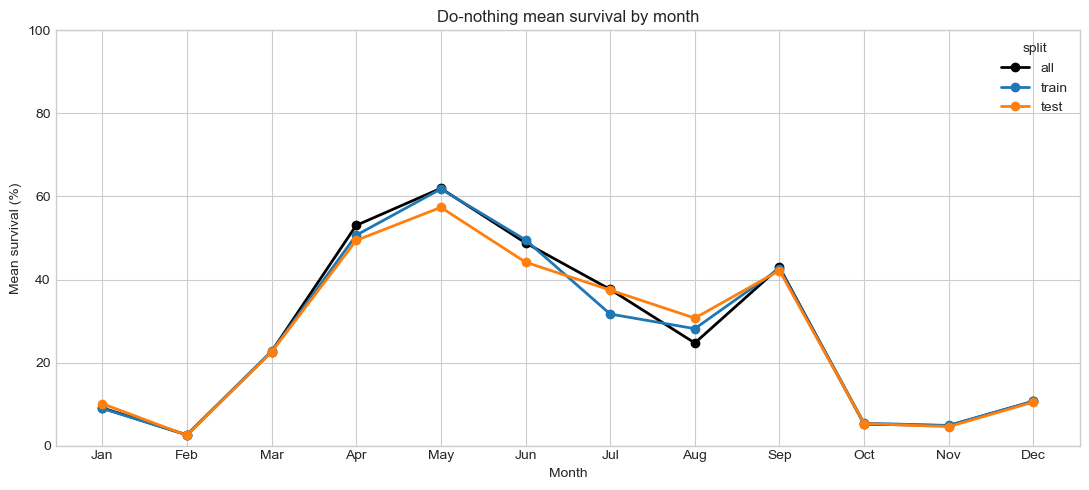

In [6]:
plot_paths = [files["csv"] for files in source_files["do_nothing"].values()]
print_plot_sources("do-nothing monthly mean survival", plot_paths)

fig, ax = plt.subplots(figsize=(11, 5))
for split, color in [("all", "black"), ("train", "tab:blue"), ("test", "tab:orange")]:
    sub = do_nothing_month[do_nothing_month["dataset_split"] == split]
    ax.plot(sub["month_num"], sub["mean_survival_pct"], marker="o", linewidth=2, label=split, color=color)
ax.set_xticks(range(1, 13), MONTH_NAMES)
ax.set_ylabel("Mean survival (%)")
ax.set_xlabel("Month")
ax.set_title("Do-nothing mean survival by month")
ax.legend(title="split")
ax.set_ylim(0, max(100, do_nothing_month["mean_survival_pct"].max() * 1.08))
fig.tight_layout()
plt.show()

Plot source files for do-nothing monthly counts and full-survival rates:
  - outputs/do_nothing_eval/wcci_train_detmaint/do_nothing_episodes.csv
  - outputs/do_nothing_eval/wcci_test_detmaint/do_nothing_episodes.csv
  - outputs/do_nothing_eval/wcci_all_detmaint/do_nothing_episodes.csv


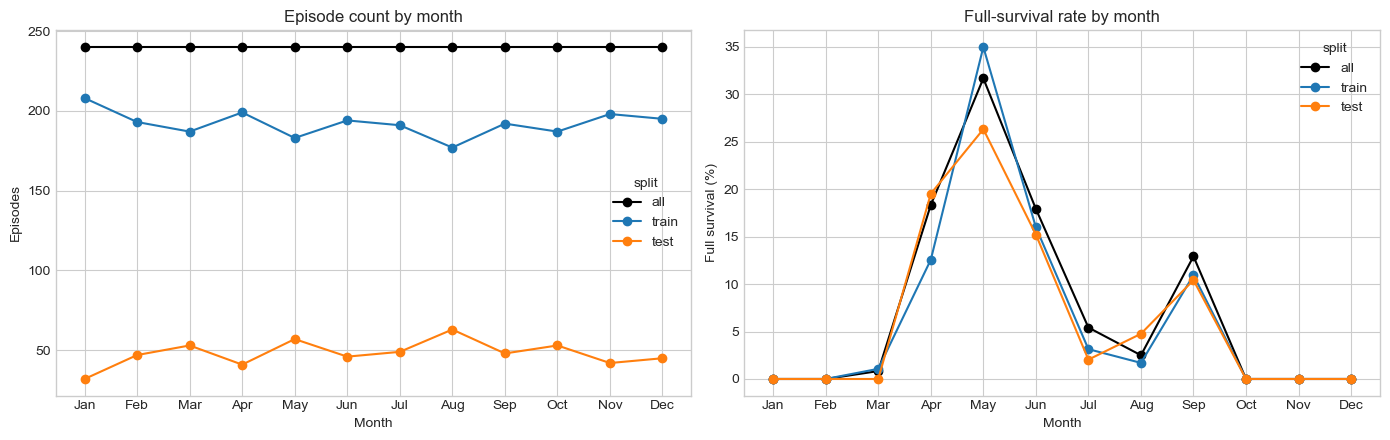

In [7]:
print_plot_sources("do-nothing monthly counts and full-survival rates", plot_paths)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
for split, color in [("all", "black"), ("train", "tab:blue"), ("test", "tab:orange")]:
    sub = do_nothing_month[do_nothing_month["dataset_split"] == split]
    axes[0].plot(sub["month_num"], sub["n"], marker="o", label=split, color=color)
    axes[1].plot(sub["month_num"], sub["full_survival_rate_pct"], marker="o", label=split, color=color)
axes[0].set_title("Episode count by month")
axes[0].set_ylabel("Episodes")
axes[1].set_title("Full-survival rate by month")
axes[1].set_ylabel("Full survival (%)")
for ax in axes:
    ax.set_xticks(range(1, 13), MONTH_NAMES)
    ax.set_xlabel("Month")
    ax.legend(title="split")
fig.tight_layout()
plt.show()

## 3. Greedy 50-Chronic Sample By Month

In [8]:
greedy_month = (
    greedy.groupby(["month_num", "month"], dropna=False)
    .agg(
        n=("greedy_survival", "size"),
        mean_greedy_survival_pct=("greedy_survival", lambda s: 100.0 * s.mean()),
        median_greedy_survival_pct=("greedy_survival", lambda s: 100.0 * s.median()),
        greedy_full_survival_rate_pct=("greedy_full_survival", lambda s: 100.0 * s.mean()),
        mean_nonidle_actions=("greedy_nonidle_actions", "mean"),
        mean_decision_states=("greedy_decision_states", "mean"),
        mean_simulated_actions=("greedy_simulated_actions", "mean"),
    )
    .reset_index()
    .sort_values("month_num")
)

display(greedy_month.round(3))

,month_num,month,n,mean_greedy_survival_pct,median_greedy_survival_pct,greedy_full_survival_rate_pct,mean_nonidle_actions,mean_decision_states,mean_simulated_actions
0,1,Jan,1,100.000,100.000,100.000,365.000,395.000,281635.000
1,2,Feb,3,73.034,100.000,66.667,128.333,132.667,94591.333
2,3,Mar,7,73.254,100.000,71.429,34.714,40.143,28621.857
3,4,Apr,8,67.024,100.000,62.500,41.000,48.000,34224.000
4,5,May,4,79.165,81.878,50.000,74.250,77.250,55079.250
5,6,Jun,5,88.841,100.000,80.000,30.800,30.800,21960.400
6,7,Jul,4,28.495,25.248,0.000,50.500,54.000,38502.000
7,8,Aug,6,57.701,55.687,33.333,78.667,101.667,72488.333
8,9,Sep,1,100.000,100.000,100.000,6.000,6.000,4278.000
9,10,Oct,4,26.662,28.194,0.000,97.500,103.500,73795.500


Plot source files for greedy sampled chronics monthly survival:
  - outputs/wcci_h1_mk256_test_50chronics_nodn/greedy_vs_do_nothing_episodes.csv


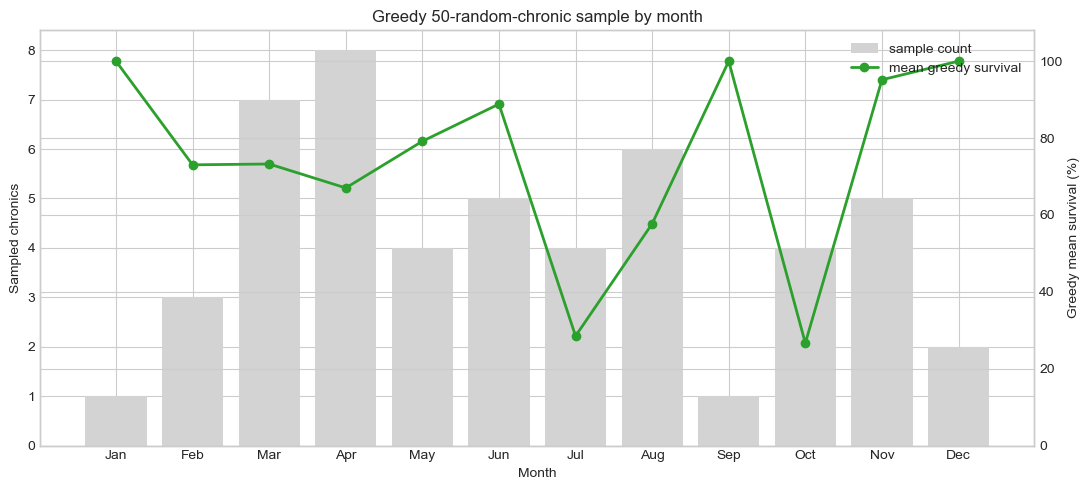

In [9]:
print_plot_sources("greedy sampled chronics monthly survival", [greedy_files["csv"]])

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(greedy_month["month_num"], greedy_month["n"], color="lightgray", label="sample count")
ax1.set_ylabel("Sampled chronics")
ax1.set_xlabel("Month")
ax1.set_xticks(range(1, 13), MONTH_NAMES)

ax2 = ax1.twinx()
ax2.plot(greedy_month["month_num"], greedy_month["mean_greedy_survival_pct"], marker="o", linewidth=2, color="tab:green", label="mean greedy survival")
ax2.set_ylabel("Greedy mean survival (%)")
ax2.set_ylim(0, max(100, greedy_month["mean_greedy_survival_pct"].max() * 1.08))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax1.set_title("Greedy 50-random-chronic sample by month")
fig.tight_layout()
plt.show()

## 4. Greedy Vs Do-Nothing On The Same Sample

If `GREEDY_RUN` points to a paired rerun with `COMPARE_DO_NOTHING=true`, this section uses the replayed do-nothing values from the greedy CSV.

Otherwise, it matches the 50 greedy chronics to the downloaded full-test do-nothing CSV by chronic fingerprint.

In [10]:
paired_available = "do_nothing_survival" in greedy and greedy["do_nothing_survival"].notna().any()

if paired_available:
    comparison = greedy.copy()
    comparison["baseline_source"] = "paired do-nothing replay inside greedy CSV"
    comparison["baseline_survival"] = comparison["do_nothing_survival"]
    comparison["baseline_full_survival"] = comparison["do_nothing_full_survival"]
    comparison["baseline_steps"] = comparison["do_nothing_steps"]
    comparison["baseline_chronic_name"] = comparison["do_nothing_chronic_name"]
    comparison["baseline_chronic_fingerprint"] = comparison["do_nothing_chronic_fingerprint"]
    comparison_sources = [greedy_files["csv"]]
else:
    test_baseline = (
        do_nothing[do_nothing["dataset_split"] == "test"]
        .rename(columns={
            "survival": "baseline_survival",
            "full_survival": "baseline_full_survival",
            "steps": "baseline_steps",
            "chronic_name": "baseline_chronic_name",
            "chronic_fingerprint": "baseline_chronic_fingerprint",
            "chronic_seed": "baseline_chronic_seed",
        })
    )
    comparison = greedy.merge(
        test_baseline[["baseline_chronic_fingerprint", "baseline_chronic_name", "baseline_survival", "baseline_full_survival", "baseline_steps", "baseline_chronic_seed"]],
        left_on="greedy_chronic_fingerprint",
        right_on="baseline_chronic_fingerprint",
        how="left",
    )
    comparison["baseline_source"] = "downloaded full-test do-nothing CSV matched by fingerprint"
    comparison_sources = [greedy_files["csv"], source_files["do_nothing"]["test"]["csv"]]

comparison["delta_vs_baseline"] = comparison["greedy_survival"] - comparison["baseline_survival"]
match_rate = comparison["baseline_survival"].notna().mean()
print(f"Paired replay available in greedy CSV: {paired_available}")
print(f"Baseline match rate: {100 * match_rate:.1f}%")
print(f"Baseline source: {comparison['baseline_source'].iloc[0] if len(comparison) else 'none'}")

sample_summary = pd.DataFrame([{
    "n": len(comparison),
    "greedy_mean_survival_pct": 100.0 * comparison["greedy_survival"].mean(),
    "baseline_mean_survival_pct": 100.0 * comparison["baseline_survival"].mean(),
    "mean_delta_pct": 100.0 * comparison["delta_vs_baseline"].mean(),
    "greedy_full_survival_rate_pct": 100.0 * comparison["greedy_full_survival"].mean(),
    "baseline_full_survival_rate_pct": 100.0 * as_bool(comparison["baseline_full_survival"]).mean(),
}])
display(sample_summary.round(3))

display(comparison[[
    "episode", "requested_chronic_id", "month", "greedy_chronic_name", "baseline_chronic_name",
    "greedy_survival", "baseline_survival", "delta_vs_baseline", "greedy_full_survival", "baseline_full_survival",
    "greedy_nonidle_actions", "greedy_decision_states"
]].sort_values("delta_vs_baseline").round(4))

Paired replay available in greedy CSV: False
Baseline match rate: 100.0%
Baseline source: downloaded full-test do-nothing CSV matched by fingerprint


,n,greedy_mean_survival_pct,baseline_mean_survival_pct,mean_delta_pct,greedy_full_survival_rate_pct,baseline_full_survival_rate_pct
0,50,69.431,28.099,41.333,56.0,6.0


,episode,requested_chronic_id,month,greedy_chronic_name,baseline_chronic_name,greedy_survival,baseline_survival,delta_vs_baseline,greedy_full_survival,baseline_full_survival,greedy_nonidle_actions,greedy_decision_states
8,8,45,Aug,Scenario_august_025,Scenario_august_025,0.0134,1.0000,-0.9866,False,True,1,1
47,47,368,Mar,Scenario_march_207,Scenario_march_207,0.0681,0.4412,-0.3731,False,False,14,52
32,32,1,Apr,Scenario_april_012,Scenario_april_012,0.0861,0.4071,-0.3210,False,False,76,99
19,19,383,May,Scenario_may_053,Scenario_may_053,0.5290,0.7997,-0.2707,False,False,94,101
10,10,271,Jul,Scenario_july_212,Scenario_july_212,0.3116,0.5476,-0.2360,False,False,27,31
27,27,3,Apr,Scenario_april_028,Scenario_april_028,0.1563,0.3490,-0.1928,False,False,8,8
24,24,371,Mar,Scenario_march_217,Scenario_march_217,0.0597,0.1987,-0.1390,False,False,17,17
41,41,239,Jul,Scenario_july_078,Scenario_july_078,0.0852,0.1924,-0.1072,False,False,2,3
16,16,21,Apr,Scenario_april_096,Scenario_april_096,0.1196,0.1213,-0.0017,False,False,57,81
6,6,49,Aug,Scenario_august_048,Scenario_august_048,0.3349,0.3360,-0.0011,False,False,13,13


In [11]:
comparison_month = (
    comparison.groupby(["month_num", "month"], dropna=False)
    .agg(
        n=("greedy_survival", "size"),
        greedy_mean_survival_pct=("greedy_survival", lambda s: 100.0 * s.mean()),
        baseline_mean_survival_pct=("baseline_survival", lambda s: 100.0 * s.mean()),
        mean_delta_pct=("delta_vs_baseline", lambda s: 100.0 * s.mean()),
        greedy_full_survival_rate_pct=("greedy_full_survival", lambda s: 100.0 * s.mean()),
        baseline_full_survival_rate_pct=("baseline_full_survival", lambda s: 100.0 * as_bool(s).mean()),
    )
    .reset_index()
    .sort_values("month_num")
)

display(comparison_month.round(3))

,month_num,month,n,greedy_mean_survival_pct,baseline_mean_survival_pct,mean_delta_pct,greedy_full_survival_rate_pct,baseline_full_survival_rate_pct
0,1,Jan,1,100.000,5.234,94.766,100.000,0.000
1,2,Feb,3,73.034,1.782,71.252,66.667,0.000
2,3,Mar,7,73.254,20.046,53.207,71.429,0.000
3,4,Apr,8,67.024,46.944,20.080,62.500,12.500
4,5,May,4,79.165,70.153,9.011,50.000,25.000
5,6,Jun,5,88.841,28.571,60.270,80.000,0.000
6,7,Jul,4,28.495,28.129,0.366,0.000,0.000
7,8,Aug,6,57.701,37.716,19.985,33.333,16.667
8,9,Sep,1,100.000,47.842,52.158,100.000,0.000
9,10,Oct,4,26.662,5.678,20.984,0.000,0.000


Plot source files for greedy vs matched do-nothing monthly comparison:
  - outputs/wcci_h1_mk256_test_50chronics_nodn/greedy_vs_do_nothing_episodes.csv
  - outputs/do_nothing_eval/wcci_test_detmaint/do_nothing_episodes.csv


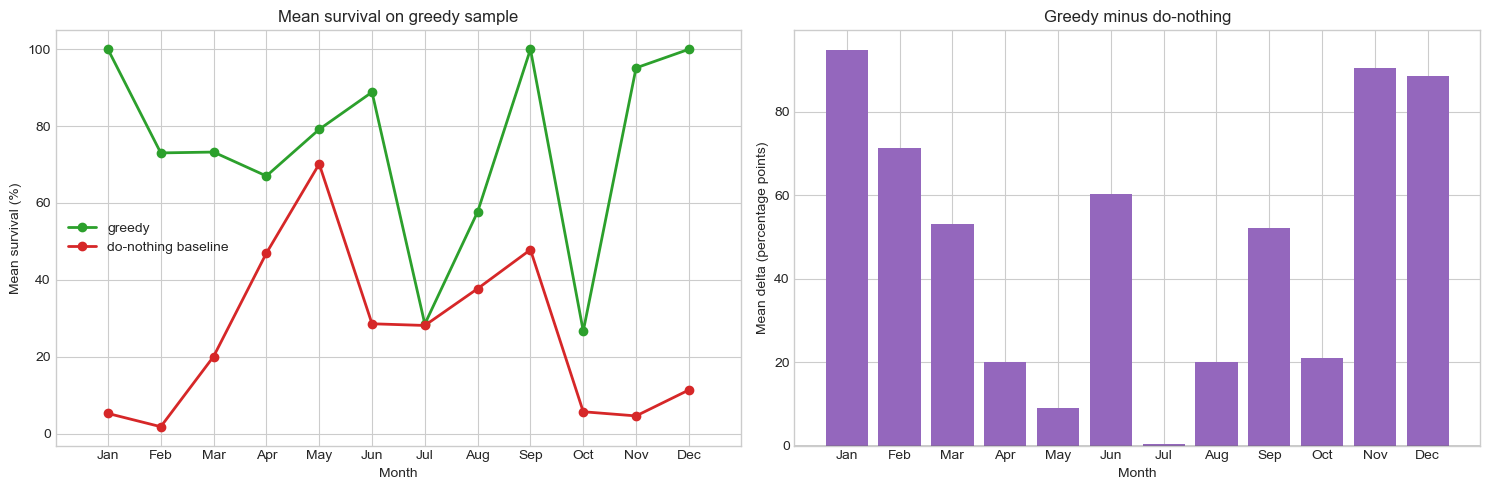

In [12]:
print_plot_sources("greedy vs matched do-nothing monthly comparison", comparison_sources)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
axes[0].plot(comparison_month["month_num"], comparison_month["greedy_mean_survival_pct"], marker="o", linewidth=2, label="greedy", color="tab:green")
axes[0].plot(comparison_month["month_num"], comparison_month["baseline_mean_survival_pct"], marker="o", linewidth=2, label="do-nothing baseline", color="tab:red")
axes[0].set_title("Mean survival on greedy sample")
axes[0].set_ylabel("Mean survival (%)")
axes[0].legend()

axes[1].bar(comparison_month["month_num"], comparison_month["mean_delta_pct"], color="tab:purple")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Greedy minus do-nothing")
axes[1].set_ylabel("Mean delta (percentage points)")

for ax in axes:
    ax.set_xticks(range(1, 13), MONTH_NAMES)
    ax.set_xlabel("Month")
fig.tight_layout()
plt.show()

Plot source files for per-chronic greedy vs do-nothing scatter:
  - outputs/wcci_h1_mk256_test_50chronics_nodn/greedy_vs_do_nothing_episodes.csv
  - outputs/do_nothing_eval/wcci_test_detmaint/do_nothing_episodes.csv


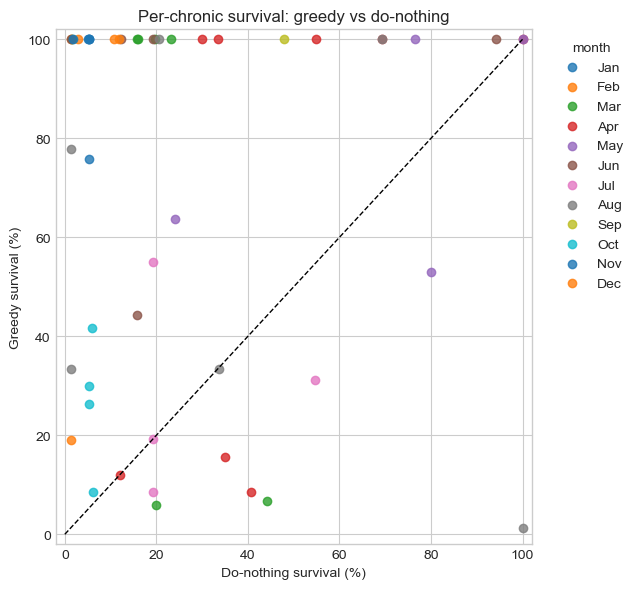

In [13]:
print_plot_sources("per-chronic greedy vs do-nothing scatter", comparison_sources)

fig, ax = plt.subplots(figsize=(6.5, 6))
valid = comparison.dropna(subset=["baseline_survival", "greedy_survival"])
for month_num, sub in valid.groupby("month_num"):
    label = MONTH_NAMES[int(month_num) - 1] if pd.notna(month_num) else "unknown"
    ax.scatter(100 * sub["baseline_survival"], 100 * sub["greedy_survival"], alpha=0.8, label=label)
ax.plot([0, 100], [0, 100], color="black", linestyle="--", linewidth=1)
ax.set_xlim(-2, 102)
ax.set_ylim(-2, 102)
ax.set_xlabel("Do-nothing survival (%)")
ax.set_ylabel("Greedy survival (%)")
ax.set_title("Per-chronic survival: greedy vs do-nothing")
ax.legend(title="month", bbox_to_anchor=(1.03, 1), loc="upper left")
fig.tight_layout()
plt.show()

## 5. Sample Coverage Audit

In [14]:
test_month_counts = (
    do_nothing[do_nothing["dataset_split"] == "test"]
    .groupby(["month_num", "month"])
    .size()
    .rename("test_count")
    .reset_index()
)
sample_month_counts = (
    greedy.groupby(["month_num", "month"])
    .size()
    .rename("sample_count")
    .reset_index()
)
coverage = test_month_counts.merge(sample_month_counts, on=["month_num", "month"], how="left").fillna({"sample_count": 0})
coverage["sample_pct_of_test_month"] = 100.0 * coverage["sample_count"] / coverage["test_count"]
display(coverage.sort_values("month_num").round(3))

display(greedy[[
    "episode", "requested_chronic_id", "month", "greedy_chronic_name", "greedy_chronic_path",
    "greedy_chronic_index", "greedy_chronic_order_position", "greedy_chronic_fingerprint", "greedy_survival", "greedy_full_survival"
]].sort_values("episode").round(4))

,month_num,month,test_count,sample_count,sample_pct_of_test_month
0,1,Jan,32,1,3.125
1,2,Feb,47,3,6.383
2,3,Mar,53,7,13.208
3,4,Apr,41,8,19.512
4,5,May,57,4,7.018
5,6,Jun,46,5,10.870
6,7,Jul,49,4,8.163
7,8,Aug,63,6,9.524
8,9,Sep,48,1,2.083
9,10,Oct,53,4,7.547


,episode,requested_chronic_id,month,greedy_chronic_name,greedy_chronic_path,greedy_chronic_index,greedy_chronic_order_position,greedy_chronic_fingerprint,greedy_survival,greedy_full_survival
0,0,40,Aug,Scenario_august_006,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,246,41,7f8af605da60,0.7788,False
1,1,16,Apr,Scenario_april_075,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,75,17,937009628edf,1.0000,True
2,2,471,Nov,Scenario_november_236,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,2396,472,47aa209e0744,0.7580,False
3,3,448,Nov,Scenario_november_094,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,2254,449,3250581617b6,1.0000,True
4,4,395,May,Scenario_may_095,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,2015,396,8456a383de30,1.0000,True
5,5,473,Nov,Scenario_november_238,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,2398,474,9ecd96762faa,1.0000,True
6,6,49,Aug,Scenario_august_048,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,288,50,b3bd6a57b42c,0.3349,False
7,7,270,Jul,Scenario_july_209,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,1409,271,6387af2b43f6,0.5496,False
8,8,45,Aug,Scenario_august_025,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,265,46,95a275417a81,0.0134,False
9,9,142,Dec,Scenario_december_191,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,671,143,4516f01947a9,1.0000,True


Plot source files for test distribution vs greedy sample distribution:
  - outputs/do_nothing_eval/wcci_test_detmaint/do_nothing_episodes.csv
  - outputs/wcci_h1_mk256_test_50chronics_nodn/greedy_vs_do_nothing_episodes.csv


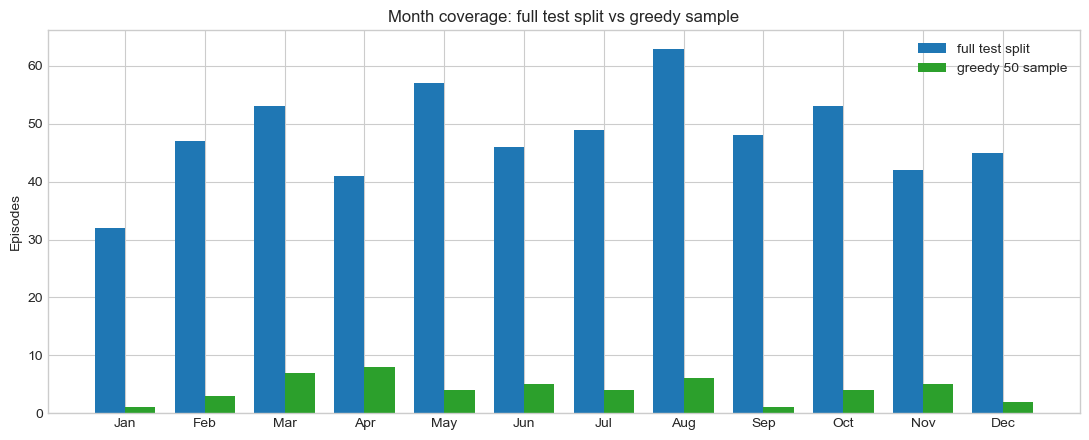

In [15]:
print_plot_sources("test distribution vs greedy sample distribution", [source_files["do_nothing"]["test"]["csv"], greedy_files["csv"]])

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(1, 13)
width = 0.38
full_counts = coverage.set_index("month_num").reindex(x)["test_count"].fillna(0)
sample_counts = coverage.set_index("month_num").reindex(x)["sample_count"].fillna(0)
ax.bar(x - width / 2, full_counts, width=width, label="full test split", color="tab:blue")
ax.bar(x + width / 2, sample_counts, width=width, label="greedy 50 sample", color="tab:green")
ax.set_xticks(x, MONTH_NAMES)
ax.set_ylabel("Episodes")
ax.set_title("Month coverage: full test split vs greedy sample")
ax.legend()
fig.tight_layout()
plt.show()

## 6. When The Paired Greedy-With-Do-Nothing Run Finishes

Download the paired folder, then change `GREEDY_RUN` in the configuration cell to that folder and rerun the notebook.

The comparison section will automatically use the paired `do_nothing_survival` values instead of the baseline matched from the full test CSV.

In [16]:
candidate_greedy_folders = sorted(OUTPUTS_DIR.glob("*wcci_h1_mk256_test*")) + sorted((OUTPUTS_DIR / "teacher_student_greedy_eval").glob("*wcci_h1_mk256_test*"))
rows = []
for folder in candidate_greedy_folders:
    csv_path = folder / "greedy_vs_do_nothing_episodes.csv"
    summary_path = folder / "greedy_vs_do_nothing_summary.json"
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)
    rows.append({
        "folder": rel(folder),
        "episodes": len(df),
        "has_paired_do_nothing": "do_nothing_survival" in df and pd.to_numeric(df.get("do_nothing_survival"), errors="coerce").notna().any(),
        "mean_greedy_survival_pct": 100.0 * pd.to_numeric(df["greedy_survival"], errors="coerce").mean(),
        "summary_exists": summary_path.exists(),
    })

display(pd.DataFrame(rows).sort_values("folder") if rows else pd.DataFrame(columns=["folder", "episodes", "has_paired_do_nothing", "mean_greedy_survival_pct", "summary_exists"]))

,folder,episodes,has_paired_do_nothing,mean_greedy_survival_pct,summary_exists
0,outputs/wcci_h1_mk256_test_50chronics_nodn,50,False,69.431407,True


## 7. Paper Date Labels

The paper labels in the screenshot look like `Apr_19.1`, `Apr_19.2`, etc. In this WCCI dataset, the natural mapping is:

`Month_XX.1 -> Scenario_month_{2*XX}`

`Month_XX.2 -> Scenario_month_{2*XX+1}`

The direct mapping `Month_XX.* -> Scenario_month_XX` is not useful because it collapses `.1` and `.2` onto the same chronic.

In [17]:
PAPER_DATE_LABELS = [
    "Apr_19.1", "Apr_19.2",
    "Aug_02.1", "Aug_02.2",
    "Dec_16.1", "Dec_16.2",
    "Feb_20.1", "Feb_20.2",
    "Jan_32.1", "Jan_32.2",
    "Jul_28.1", "Jul_28.2",
    "Jun_14.1", "Jun_14.2",
    "Mar_39.1", "Mar_39.2",
    "May_24.1", "May_24.2",
    "Nov_46.1", "Nov_46.2",
    "Oct_05.1", "Oct_05.2",
    "Sep_21.1", "Sep_21.2",
]

ABBR_TO_MONTH = {
    "Jan": "january", "Feb": "february", "Mar": "march", "Apr": "april",
    "May": "may", "Jun": "june", "Jul": "july", "Aug": "august",
    "Sep": "september", "Oct": "october", "Nov": "november", "Dec": "december",
}

all_do_nothing = do_nothing[do_nothing["dataset_split"] == "all"].set_index("chronic_name")
test_names = set(do_nothing[do_nothing["dataset_split"] == "test"]["chronic_name"])
train_names = set(do_nothing[do_nothing["dataset_split"] == "train"]["chronic_name"])

paper_rows = []
for label in PAPER_DATE_LABELS:
    month_abbr, rest = label.split("_")
    base_index_text, variant_text = rest.split(".")
    base_index = int(base_index_text)
    variant = int(variant_text)
    month = ABBR_TO_MONTH[month_abbr]
    scenario_index = 2 * base_index + (variant - 1)
    chronic_name = f"Scenario_{month}_{scenario_index:03d}"
    split = "test" if chronic_name in test_names else ("train" if chronic_name in train_names else "missing")
    if chronic_name in all_do_nothing.index:
        row = all_do_nothing.loc[chronic_name]
        paper_rows.append({
            "paper_label": label,
            "wcci_chronic": chronic_name,
            "global_index": int(row["chronic_index"]),
            "split_seed0": split,
            "do_nothing_survival_pct": 100.0 * float(row["survival"]),
            "full_survival": bool(row["full_survival"]),
            "fingerprint": row["chronic_fingerprint"],
        })
    else:
        paper_rows.append({
            "paper_label": label,
            "wcci_chronic": chronic_name,
            "global_index": scenario_index,
            "split_seed0": split,
            "do_nothing_survival_pct": np.nan,
            "full_survival": np.nan,
            "fingerprint": "missing",
        })

paper_dates = pd.DataFrame(paper_rows)
display(paper_dates.round({"do_nothing_survival_pct": 2}))
display(paper_dates["split_seed0"].value_counts().rename_axis("split_seed0").reset_index(name="n"))

,paper_label,wcci_chronic,global_index,split_seed0,do_nothing_survival_pct,full_survival,fingerprint
0,Apr_19.1,Scenario_april_038,38,train,8.56,False,20499dfb70a1
1,Apr_19.2,Scenario_april_039,39,train,65.68,False,0c7b71149dee
2,Aug_02.1,Scenario_august_004,244,train,76.66,False,8ae2f01dea75
3,Aug_02.2,Scenario_august_005,245,train,51.46,False,f63aaca15775
4,Dec_16.1,Scenario_december_032,512,train,10.22,False,e7485a84e4e5
5,Dec_16.2,Scenario_december_033,513,test,10.06,False,9232a3f3beb0
6,Feb_20.1,Scenario_february_040,760,train,1.14,False,88fcadd7c614
7,Feb_20.2,Scenario_february_041,761,train,1.29,False,497c25766736
8,Jan_32.1,Scenario_january_064,1024,train,16.00,False,7c73bc788176
9,Jan_32.2,Scenario_january_065,1025,train,7.11,False,5d3c9baa0baf


,split_seed0,n
0,train,20
1,test,4
